In [1]:
import geopandas as gpd
from shapely.geometry import Point, LineString

In [2]:
file_path = '/Users/cicitao/Desktop/SFA/Vision Zero/Data/Streets.geojson'
streets = gpd.read_file(file_path)
streets.shape

(85178, 39)

In [3]:
streets.head()

,AutoID,OBJECTID,ASSETID,INT_ID_FROM,INT_ID_TO,STNUM,MAPSHEET,ID,ADRF,ADRT,...,PLANNING_STREET_STANDARD,BSS_ST_CLASS,TOOLTIP,NLA_URL,Planning_ASSETID,TYPE,MODIFIED,Street_Designation,Street_Designation_WO_Mod,geometry
0,1,1,168,4176,4259,1736.0,099B209,7392.0,8301.0,8399.0,...,NaN,LO,WADSWORTH AVE\nStreet Designation: Local Stree...,navigatela/reports/centerline_mb.cfm?pk=168&t=...,168.0,70.0,0.0,Local Street - Standard,Local Street - Standard,"LINESTRING (-118.25859 33.96379, -118.25859 33..."
1,2,2,169,4299,1843,959.0,088-5A199,7417.0,701.0,799.0,...,NaN,LO,110TH ST\nStreet Designation: Local Street - S...,navigatela/reports/centerline_mb.cfm?pk=169&t=...,169.0,70.0,0.0,Local Street - Standard,Local Street - Standard,"LINESTRING (-118.28696 33.9356, -118.28938 33...."
2,3,3,170,4373,4390,7854.0,120B177,7460.0,2901.0,2929.0,...,NaN,LO,COCHRAN AVE\nStreet Designation: Local Street ...,navigatela/reports/centerline_mb.cfm?pk=170&t=...,170.0,70.0,0.0,Local Street - Standard,Local Street - Standard,"LINESTRING (-118.36036 34.02763, -118.36066 34..."
3,4,4,171,4465,4488,3463.0,117B181,7585.0,3601.0,3799.0,...,NaN,LO,POTOMAC AVE\nStreet Designation: Local Street ...,navigatela/reports/centerline_mb.cfm?pk=171&t=...,171.0,70.0,0.0,Local Street - Standard,Local Street - Standard,"LINESTRING (-118.34421 34.0215, -118.34421 34...."
4,5,5,172,4078,4117,2412.0,084B209,7015.0,11501.0,11599.0,...,NaN,LO,SUCCESS AVE\nStreet Designation: Local Street ...,navigatela/reports/centerline_mb.cfm?pk=172&t=...,172.0,70.0,0.0,Local Street - Standard,Local Street - Standard,"LINESTRING (-118.24928 33.93026, -118.24929 33..."


In [4]:
streets.columns

Index(['AutoID', 'OBJECTID', 'ASSETID', 'INT_ID_FROM', 'INT_ID_TO', 'STNUM',
       'MAPSHEET', 'ID', 'ADRF', 'ADRT', 'ZIP_R', 'ADLF', 'ADLT', 'ZIP_L',
       'TDIR', 'STNAME', 'STSFX', 'SFXDIR', 'STNAME_A', 'STSFX_A', 'STATUS',
       'TEMP_', 'SECT_ID', 'REMARKS', 'SV_STATUS', 'ST_SUBTYPE', 'CRTN_DT',
       'LST_MODF_DT', 'OLD_STREET_DESIGNATION', 'PLANNING_STREET_STANDARD',
       'BSS_ST_CLASS', 'TOOLTIP', 'NLA_URL', 'Planning_ASSETID', 'TYPE',
       'MODIFIED', 'Street_Designation', 'Street_Designation_WO_Mod',
       'geometry'],
      dtype='str')

In [5]:
file_path = '/Users/cicitao/Desktop/SFA/Vision Zero/Data/Crosswalks/Crosswalks.shp'
crosswalks = gpd.read_file(file_path)
crosswalks.shape

(22034, 17)

In [6]:
crosswalks.head()

,ID,ObjectID,Source,Date_,Control,Location,Color,Ladder,Primary_St,Cross_Stre,CrossType,CrosswalkC,ControlTyp,MarkingTyp,TOOLTIP,NLA_URL,geometry
0,1,1,None,2005-11-01,1,318.0,0.0,None,WOODMAN AV,LASSEN ST,White Controlled Crosswalk,White,Signal,Continental,Crosswalk Color: White\nControl Type: Signal\n...,navigatela/reports/dot_crosswalks_report.cfm?pk=1,POINT (-13185863.986 4062516.658)
1,2,2,None,2005-11-01,1,228.0,0.0,None,LASSEN ST,WOODMAN AV,White Controlled Crosswalk,White,Signal,Continental,Crosswalk Color: White\nControl Type: Signal\n...,navigatela/reports/dot_crosswalks_report.cfm?pk=2,POINT (-13185869.769 4062492.891)
2,3,3,None,2005-11-01,1,138.0,0.0,None,WOODMAN AV,LASSEN ST,White Controlled Crosswalk,White,Signal,Continental,Crosswalk Color: White\nControl Type: Signal\n...,navigatela/reports/dot_crosswalks_report.cfm?pk=3,POINT (-13185846.878 4062489.264)
3,4,4,None,2005-11-01,1,48.0,0.0,None,FILMORE ST,WOODMAN AV,White Controlled Crosswalk,White,Signal,Continental,Crosswalk Color: White\nControl Type: Signal\n...,navigatela/reports/dot_crosswalks_report.cfm?pk=4,POINT (-13185839.711 4062516.563)
4,5,5,None,2005-11-01,1,270.0,0.0,None,DEVONSHIRE ST,SEPULVEDA BL,White Controlled Crosswalk,White,Signal,Continental,Crosswalk Color: White\nControl Type: Signal\n...,navigatela/reports/dot_crosswalks_report.cfm?pk=5,POINT (-13187756.455 4063403.496)


In [7]:
import numpy as np

def nearest_valid_distance(row, gdf, min_radius=100):

    # Same Primary Street
    subset = gdf[gdf["Primary_St"] == row["Primary_St"]]

    # Different Cross Street
    subset = subset[subset["Cross_Stre"] != row["Cross_Stre"]]

    # Remove self safely
    subset = subset[subset.index != row.name]

    if subset.empty:
        return np.nan

    # Compute distances
    distances = subset.geometry.distance(row.geometry)

    # Keep only > 100 ft
    valid_distances = distances[distances > min_radius]

    if valid_distances.empty:
        return np.nan

    return valid_distances.min()

In [8]:
crosswalks["nearest_same_primary_ft"] = crosswalks.apply(
    lambda row: nearest_valid_distance(row, crosswalks, min_radius=100),
    axis=1
)

In [9]:
print(crosswalks["nearest_same_primary_ft"].describe())

# See rows where no valid match found
print(crosswalks[crosswalks["nearest_same_primary_ft"].isna()])

count    19724.000000
mean       796.665917
std       2208.580132
min        100.046902
25%        201.290972
50%        333.849970
75%        578.959875
max      58500.401478
Name: nearest_same_primary_ft, dtype: float64
          ID  ObjectID Source      Date_  Control  Location  Color Ladder  \
135      136       136   None 2005-11-01        1       0.0    1.0   None   
137      138       138   None 2005-11-01        1     180.0    1.0   None   
167      168       168   None 2005-12-01        1     225.0    0.0   None   
173      174       174   None 2005-12-01        2     135.0    1.0   None   
182      183       183   None 2005-12-01        2      45.0    1.0   None   
...      ...       ...    ...        ...      ...       ...    ...    ...   
21993  21994     21994   None 2024-09-30        2     297.0    0.0   None   
21996  21997     21997   None        NaT        2     295.0    1.0   None   
22002  22003     22003   None        NaT        2      90.0    1.0   None   
22017  2

In [10]:
crosswalks["nearest_same_primary_ft"].quantile([0.90, 0.95, 0.98, 0.99])

0.90    1434.508318
0.95    2533.673272
0.98    5570.579444
0.99    9259.837750
Name: nearest_same_primary_ft, dtype: float64

In [11]:
cleaned = crosswalks[
    crosswalks["nearest_same_primary_ft"] <= 10560
]
cleaned["nearest_same_primary_ft"].describe()

count    19570.000000
mean       642.981118
std       1052.585211
min        100.046902
25%        199.933718
50%        329.479292
75%        557.173310
max      10451.907705
Name: nearest_same_primary_ft, dtype: float64

Street designation and merging

In [12]:
suffix_map = {
    "AV": "AVE",
    "AVE": "AVE",
    "AVENUE": "AVE",
    
    "BL": "BLVD",
    "BLVD": "BLVD",
    "BOULEVARD": "BLVD",
    
    "ST": "ST",
    "STREET": "ST",
    
    "RD": "RD",
    "ROAD": "RD",
    
    "DR": "DR",
    "DRIVE": "DR",
    
    "LN": "LN",
    "LANE": "LN",
    
    "PL": "PL",
    "PLACE": "PL",
    
    "CT": "CT",
    "COURT": "CT"
}

In [13]:
# Make uppercase & strip
cleaned["Primary_St"] = cleaned["Primary_St"].str.upper().str.strip()

# Split into parts
cleaned[["STNAME_clean", "STSFX_clean"]] = (
    cleaned["Primary_St"]
    .str.rsplit(" ", n=1, expand=True)
)

# Standardize suffix for crosswalks
cleaned["STSFX_clean"] = cleaned["STSFX_clean"].map(suffix_map)

# Create normalized street key
cleaned["street_key"] = (
    cleaned["STNAME_clean"] + "_" + cleaned["STSFX_clean"]
)

In [14]:
streets["STNAME"] = streets["STNAME"].str.upper().str.strip()
streets["STSFX"] = streets["STSFX"].str.upper().str.strip()

# Standardize suffix for streets too
streets["STSFX"] = streets["STSFX"].map(suffix_map)

streets["street_key"] = streets["STNAME"] + "_" + streets["STSFX"]

In [15]:
# Force ONE designation per street_key, based on most common designation
streets_designation = (
    streets
    .groupby("street_key")["Street_Designation_WO_Mod"]
    .agg(lambda x: x.mode()[0])
    .reset_index()
)

In [ ]:
# should be 0
streets_designation["street_key"].duplicated().sum()

np.int64(0)

In [17]:
# merge streets classifications with crosswalks
cleaned_with_designation = cleaned.merge(
    streets_designation,
    on="street_key",
    how="left"
)

Create and export a new geojson to keep only arterials.

In [ ]:
# Keep Only Selected Street Designations
keep_designations = [
    "Avenue I",
    "Avenue II",
    "Avenue III",
    "Boulevard I",
    "Boulevard II",
    "Collector",
    "Industrial Collector",
    "Mountain Collector"
]

# Filter dataset
arterials_only = cleaned_with_designation[
    cleaned_with_designation["Street_Designation_WO_Mod"].isin(keep_designations)
].copy()

# Check result
print("Original features:", len(cleaned_with_designation))
print("Filtered features:", len(arterials_only))

# Optional: inspect remaining classifications
print(
    arterials_only["Street_Designation_WO_Mod"]
    .value_counts()
)

# Export Updated GeoJSON
output_path = "/Users/cicitao/Desktop/SFA/Vision Zero/Data/Crosswalks_Arterials_Only.geojson"

arterials_only.to_file(output_path, driver="GeoJSON")

print(f"Exported updated GeoJSON to:\n{output_path}")

Original features: 19570
Filtered features: 13280
Street_Designation_WO_Mod
Avenue II               4717
Collector               3311
Avenue I                2441
Boulevard II            2296
Avenue III               363
Boulevard I              131
Industrial Collector      15
Mountain Collector         6
Name: count, dtype: int64
Exported updated GeoJSON to:
/Users/cicitao/Desktop/SFA/Vision Zero/Data/Crosswalks_Arterials_Only.geojson


Export excel + Neighborhood level analysis

In [ ]:
import geopandas as gpd
import pandas as pd

# 1️⃣ KEEP ONLY SELECTED STREET DESIGNATIONS

keep_designations = [
    "Avenue I",
    "Avenue II",
    "Avenue III",
    "Boulevard I",
    "Boulevard II",
    "Collector",
    "Industrial Collector",
    "Mountain Collector"
]

# Copy dataset
df = cleaned_with_designation.copy()

# Keep only rows with spacing values
df = df[df["nearest_same_primary_ft"].notna()]

# Apply designation filter
df_filtered = df[
    df["Street_Designation_WO_Mod"].isin(keep_designations)
].copy()

print("Filtered crosswalk count:", len(df_filtered))

# 2️⃣ STREET-LEVEL STATISTICS

street_summary = (
    df_filtered.groupby(
        ["Primary_St", "Street_Designation_WO_Mod"],
        sort=False
    )["nearest_same_primary_ft"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

street_summary.columns = [
    "Primary_St",
    "Street_Designation",
    "Mean_Spacing_ft",
    "Median_Spacing_ft",
    "Crosswalk_Count"
]

# 3️⃣ STREET DESIGNATION STATISTICS

class_summary = (
    df_filtered.groupby(
        "Street_Designation_WO_Mod",
        sort=False
    )["nearest_same_primary_ft"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

class_summary.columns = [
    "Street_Designation",
    "Mean_Spacing_ft",
    "Median_Spacing_ft",
    "Crosswalk_Count"
]

# 4️⃣ CITYWIDE STATISTICS

citywide_mean = df_filtered["nearest_same_primary_ft"].mean()
citywide_median = df_filtered["nearest_same_primary_ft"].median()
citywide_count = df_filtered["nearest_same_primary_ft"].count()

citywide_row = pd.DataFrame([{
    "Street_Designation": "CITYWIDE",
    "Mean_Spacing_ft": citywide_mean,
    "Median_Spacing_ft": citywide_median,
    "Crosswalk_Count": citywide_count
}])

class_summary = pd.concat(
    [class_summary, citywide_row],
    ignore_index=True
)

# 5️⃣ LOAD NEIGHBORHOOD COUNCIL POLYGONS

nc_path = "/Users/cicitao/Desktop/SFA/Vision Zero/Data/Neighborhood_Councils_(Certified).geojson"

neighborhoods = gpd.read_file(nc_path)

# Ensure same CRS
if df_filtered.crs != neighborhoods.crs:
    neighborhoods = neighborhoods.to_crs(df_filtered.crs)

# 6️⃣ SPATIAL JOIN (CROSSWALK → NEIGHBORHOOD)

crosswalk_nc = gpd.sjoin(
    df_filtered,
    neighborhoods,
    how="left",
    predicate="intersects"
)

# Check join results
print("Filtered crosswalks:", len(df_filtered))
print("Matched to neighborhoods:", crosswalk_nc["NAME"].notna().sum())
print("Unmatched:", crosswalk_nc["NAME"].isna().sum())

# 7️⃣ NEIGHBORHOOD-LEVEL STATISTICS

neighborhood_summary = (
    crosswalk_nc.groupby(
        "NAME",
        sort=False
    )["nearest_same_primary_ft"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

neighborhood_summary.columns = [
    "Neighborhood_Council",
    "Mean_Spacing_ft",
    "Median_Spacing_ft",
    "Crosswalk_Count"
]

# 8️⃣ EXPORT SINGLE EXCEL FILE (3 TABS)

excel_output = "/Users/cicitao/Desktop/SFA/Vision Zero/Data/Output/Crosswalk_Distance_Summary_Arterials.xlsx"

with pd.ExcelWriter(excel_output, engine="openpyxl") as writer:

    street_summary.to_excel(
        writer,
        sheet_name="Street_Level_Spacing",
        index=False
    )

    class_summary.to_excel(
        writer,
        sheet_name="Designation_and_Citywide",
        index=False
    )

    neighborhood_summary.to_excel(
        writer,
        sheet_name="Neighborhood_Council_Stats",
        index=False
    )

print("Excel file saved:")
print(excel_output)

# 9️⃣ CREATE NEIGHBORHOOD GEOJSON

neighborhood_stats = (
    crosswalk_nc.groupby("NAME")["nearest_same_primary_ft"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

neighborhood_stats.columns = [
    "NAME",
    "Mean_Spacing_ft",
    "Median_Spacing_ft",
    "Crosswalk_Count"
]

# Join stats back to polygons
neighborhoods_with_stats = neighborhoods.merge(
    neighborhood_stats,
    on="NAME",
    how="left"
)

# Convert to GeoJSON CRS
neighborhoods_with_stats = neighborhoods_with_stats.to_crs(epsg=4326)

# Export GeoJSON
geojson_output = "/Users/cicitao/Desktop/SFA/Vision Zero/Data/Output/Neighborhood_Crosswalk_Spacing_Arterials.geojson"

neighborhoods_with_stats.to_file(
    geojson_output,
    driver="GeoJSON"
)

print("GeoJSON saved:")
print(geojson_output)

Filtered crosswalk count: 13280
Filtered crosswalks: 13280
Matched to neighborhoods: 12909
Unmatched: 484
Excel file saved:
/Users/cicitao/Desktop/SFA/Vision Zero/Data/Output/Crosswalk_Distance_Summary_Arterials.xlsx
GeoJSON saved:
/Users/cicitao/Desktop/SFA/Vision Zero/Data/Output/Neighborhood_Crosswalk_Spacing_Arterials.geojson


Calculate the % of crosswalks that's over recommended spacing, 1/4 mile, and 1/2 mile.

In [ ]:
# Load GeoJSON
gdf = gpd.read_file(
    "/Users/cicitao/Desktop/SFA/Vision Zero/Data/Output/Crosswalks_Arterials_Only.geojson"
)

# Keep only rows with valid spacing values
valid_data = gdf[gdf["nearest_same_primary_ft"].notna()]

# Total count
total = len(valid_data)

# Over recommended spacing (328 ft)
over_recommended = len(
    valid_data[valid_data["nearest_same_primary_ft"] > 328]
)

pct_recommended = (over_recommended / total) * 100

# Over 1/4 mile (1320 ft)
over_quarter = len(
    valid_data[valid_data["nearest_same_primary_ft"] > 1320]
)

pct_quarter = (over_quarter / total) * 100

# Over 1/2 mile (2640 ft)
over_half = len(
    valid_data[valid_data["nearest_same_primary_ft"] > 2640]
)

pct_half = (over_half / total) * 100

# Print results
print(f"Over 328 ft: {pct_recommended:.1f}%")
print(f"Over 1/4 mile: {pct_quarter:.1f}%")
print(f"Over 1/2 mile: {pct_half:.1f}%")

Over 328 ft: 50.8%
Over 1/4 mile: 8.1%
Over 1/2 mile: 2.9%


Drawing Histogram

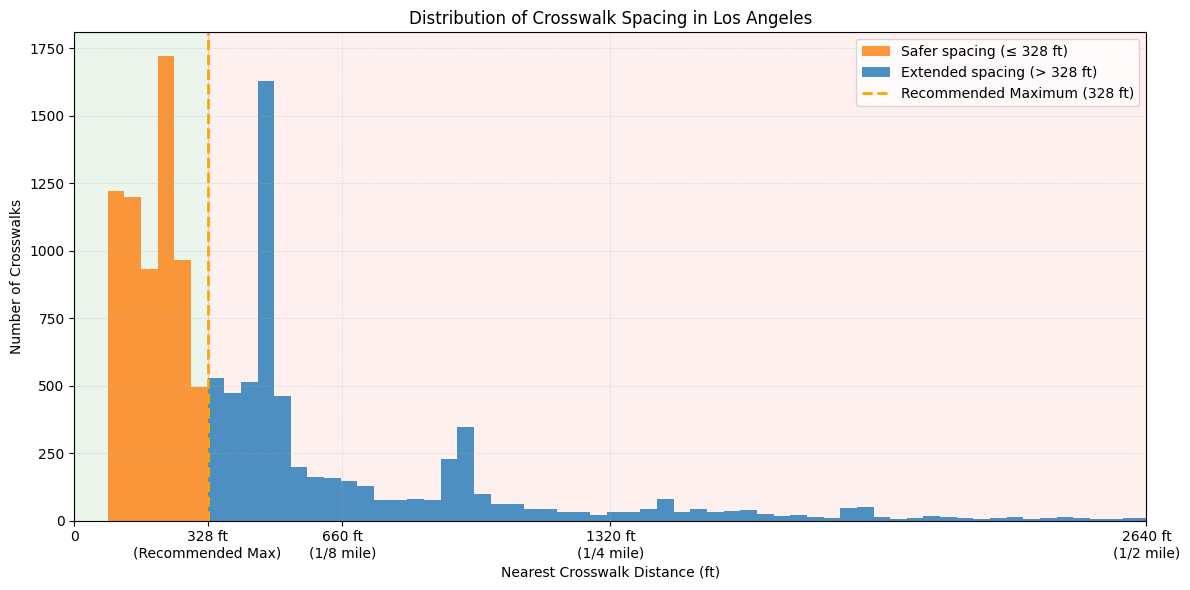

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Use valid spacing values only
data = gdf["nearest_same_primary_ft"].dropna()

# Limit histogram to 1/2 mile (2640 ft)
filtered_data = data[data <= 2640]

# Split data based on threshold
below_recommended = filtered_data[filtered_data <= 328]
above_recommended = filtered_data[filtered_data > 328]

# Create figure
plt.figure(figsize=(12,6))

bin_width = 41

start = 0
end = 2640

# shift grid so 328 is aligned to bin edges
offset = 328 % bin_width

bins = np.arange(start - offset, end + bin_width, bin_width)
bins = bins[bins >= 0]

# RED/GREEN ZONES
plt.axvspan(0, 328, color="green", alpha=0.08)
plt.axvspan(328, 2640, color="red", alpha=0.06)

# HISTOGRAMS
plt.hist(
    below_recommended,
    bins=bins,
    range=(0, 2640),
    alpha=0.8,
    label="Safer spacing (≤ 328 ft)",
    color="tab:orange"
)

plt.hist(
    above_recommended,
    bins=bins,
    range=(0, 2640),
    alpha=0.8,
    label="Extended spacing (> 328 ft)",
    color="tab:blue"
)

# THRESHOLD LINE
plt.axvline(
    328,
    linestyle='--',
    linewidth=2,
    color="orange",
    label='Recommended Maximum (328 ft)'
)

# Axis labels and title
plt.xlabel("Nearest Crosswalk Distance (ft)")
plt.ylabel("Number of Crosswalks")
plt.title("Distribution of Crosswalk Spacing in Los Angeles")

# Custom x-axis ticks
plt.xticks([
    0,
    328,
    660,
    1320,
    2640
], [
    "0",
    "328 ft\n(Recommended Max)",
    "660 ft\n(1/8 mile)",
    "1320 ft\n(1/4 mile)",
    "2640 ft\n(1/2 mile)"
])

# Grid
plt.grid(True, which="major", axis="both", linestyle="--", linewidth=0.5, alpha=0.4)

# Axis limit
plt.xlim(0, 2640)

# Legend
plt.legend()

plt.tight_layout()
plt.show()

High injury network.

In [70]:
import geopandas as gpd

# Load HIN dataset
hin = gpd.read_file(
    "/Users/cicitao/Desktop/SFA/Vision Zero/Data/LA_Vision_Zero_High_Injury_Network_(2024)_Prioritization_Data_view_1802784989270691369.geojson"
)

# Load crosswalk dataset
crosswalks = gpd.read_file(
    "/Users/cicitao/Desktop/SFA/Vision Zero/Data/Output/Crosswalks_Arterials_Only.geojson"
)

In [71]:
if crosswalks.crs != hin.crs:
    hin = hin.to_crs(crosswalks.crs)

In [72]:
# Create 50 ft buffer around HIN corridors
hin_buffer = hin.copy()
hin_buffer["geometry"] = hin_buffer.geometry.buffer(50)

In [73]:
crosswalk_hin = gpd.sjoin(
    crosswalks,
    hin_buffer,
    how="left",
    predicate="intersects"
)

In [74]:
# Crosswalks intersecting HIN get True
crosswalk_hin["On_HIN"] = (
    crosswalk_hin.index_right.notna()
)

In [75]:
summary = (
    crosswalk_hin.groupby("On_HIN")["nearest_same_primary_ft"]
    .agg(["mean", "median", "count"])
)

print(summary)

              mean      median  count
On_HIN                               
False   711.104298  452.967931   6576
True    414.405734  245.334435   8684


In [76]:
for hin_status in [True, False]:

    subset = crosswalk_hin[
        crosswalk_hin["On_HIN"] == hin_status
    ]

    total = len(subset)

    over_quarter = (
        subset["nearest_same_primary_ft"] > 1320
    ).sum()

    pct = (over_quarter / total) * 100

    print(
        f"On_HIN={hin_status}: {pct:.1f}% over 1/4 mile"
    )

On_HIN=True: 4.4% over 1/4 mile
On_HIN=False: 11.0% over 1/4 mile


In [77]:
for hin_status in [True, False]:

    subset = crosswalk_hin[
        crosswalk_hin["On_HIN"] == hin_status
    ]

    total = len(subset)

    over_recommend = (
        subset["nearest_same_primary_ft"] > 328
    ).sum()

    pct = (over_recommend / total) * 100

    print(
        f"On_HIN={hin_status}: {pct:.1f}% over recommend"
    )

On_HIN=True: 37.1% over recommend
On_HIN=False: 62.7% over recommend
